In [1]:
pwd

'C:\\Users\\rudra'

In [7]:
# Import necessary libraries
import numpy as np
# from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from scipy.spatial.distance import cosine


# Function to extract features using VGG16 and calculate cosine similarity
def calculate_feature_similarity(image_path1, image_path2):
    # Load pre-trained VGG16 model
    base_model = VGG16(weights='imagenet', include_top=False)
    model = Model(inputs=base_model.input, outputs=base_model.get_layer('block5_pool').output)
    
    # Function to preprocess image for VGG16
    def preprocess_image(image_path):
        img = image.load_img(image_path, target_size=(224, 224))
        img_data = image.img_to_array(img)
        img_data = np.expand_dims(img_data, axis=0)
        img_data = preprocess_input(img_data)
        return img_data
    
    # Preprocess the two images
    img1 = preprocess_image(image_path1)
    img2 = preprocess_image(image_path2)
    
    # Extract features
    features_img1 = model.predict(img1)
    features_img2 = model.predict(img2)
    
    # Flatten features and calculate cosine similarity
    features_img1 = features_img1.flatten()
    features_img2 = features_img2.flatten()
    similarity = 1 - cosine(features_img1, features_img2)
    
    return similarity


# Calculate feature-based similarity using VGG16
feature_similarity = calculate_feature_similarity('C:/Users/rudra/Downloads/0xMelkor_ethereum-node-original.png', 'C:/Users/rudra/Downloads/0xMelkor_ethereum-node-Few-shot.png')
print(f"Feature-based similarity (Cosine similarity): {feature_similarity}")

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/rudra/Downloads/0xMelkor_ethereum-node-original.png'

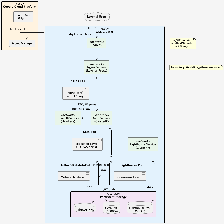

In [7]:
img = image.load_img('C:/Users/rudra/Downloads/0xMelkor_ethereum-node-Few-shot.png', target_size=(224, 224))
img

In [ ]:
import os
import csv
import numpy as np
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from scipy.spatial.distance import cosine

# ========== Image Similarity Logic ==========

def calculate_feature_similarity(image_path1, image_path2):
    base_model = VGG16(weights='imagenet', include_top=False)
    model = Model(inputs=base_model.input, outputs=base_model.get_layer('block5_pool').output)

    def preprocess_image(img_path):
        img = image.load_img(img_path, target_size=(224, 224))
        img_data = image.img_to_array(img)
        img_data = np.expand_dims(img_data, axis=0)
        img_data = preprocess_input(img_data)
        return img_data

    img1 = preprocess_image(image_path1)
    img2 = preprocess_image(image_path2)

    features1 = model.predict(img1).flatten()
    features2 = model.predict(img2).flatten()

    similarity = 1 - cosine(features1, features2)
    return similarity

# ========== File Utilities ==========

def get_files_by_stem(folder):
    file_map = {}
    for fname in os.listdir(folder):
        stem, _ = os.path.splitext(fname)
        file_map[stem] = fname
    return file_map

def write_to_csv(data, output_dir="outputs", filename="image_comparisons_cosine_similarity.csv"):
    os.makedirs(output_dir, exist_ok=True)
    csv_path = os.path.join(output_dir, filename)
    with open(csv_path, mode='w', encoding='utf-8', newline='') as csvfile:
        fieldnames = ["filename", "image1", "image2", "vgg16_cosine_similarity"]
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        for row in data:
            writer.writerow(row)

# ========== Main Comparison Flow ==========

def main():
    output_dir = "outputs"
    folder1 = "./initial_images"
    folder2 = "./approach_gpt_python_images_similarity_results.csv"
    files1 = get_files_by_stem(folder1)
    files2 = get_files_by_stem(folder2)
    common_stems = sorted(set(files1.keys()) & set(files2.keys()))
    print("Started comparing image pairs...")
    all_results = []
    check=0
    for stem in common_stems:
        if check>10:
            print("⚠️ Stopping after 10 comparisons.")
            break
        path1 = os.path.join(folder1, files1[stem])
        path2 = os.path.join(folder2, files2[stem])
        try:
            similarity = calculate_feature_similarity(path1, path2)
            result = {
                "filename": stem,
                "image1": files1[stem],
                "image2": files2[stem],
                "vgg16_cosine_similarity": similarity
            }
            all_results.append(result)
            check=+1
            print(f"Compared: {stem} (similarity={similarity:.4f})")
        except Exception as e:
            print(f"Error comparing {stem}: {e}")
    if all_results:
        write_to_csv(all_results, output_dir)
        print(f"\n✅ Results written to {os.path.join(output_dir, 'image_comparisons.csv')}")
    else:
        print("⚠️ No comparisons completed successfully.")

if __name__ == "__main__":
    main()


Started comparing image pairs...
Error comparing 0xMelkor_ethereum-node: cannot identify image file <_io.BytesIO object at 0x14feb0400>
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Compared: 23fa-cpsc490_canyough (similarity=0.2830)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Compared: 2WAY_Design (similarity=0.3175)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Compared: Activiti_activiti-7-developers-guide (similarity=0.2636)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Compared: AhmedAbdelGawadFarag_Shams-Personal-Assistant (similarity=0.3261)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Compared: AmnisIO_AmnisIO (similarity=0.1960)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Compared: AndreasM009_AadApiGatekeeper (similarity=0.1595)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━